<a href="https://colab.research.google.com/github/Harukokoko/Haruka-Nakagawa/blob/main/result_HS8482_1995_2023_dlbyfree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple, Callable
import scipy as sp
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import io
import os
from google.colab import files

In [2]:
# ファイルアップロード
result_uploaded = files.upload()

# アップロードしたファイルを読み込む
result_path = list(result_uploaded.keys())[0]  # アップロードしたファイル名を取得
result = pd.read_excel(result_path, header=None)

Saving result_HS8482_1995_2023_dlbyfree.xlsx to result_HS8482_1995_2023_dlbyfree.xlsx


In [3]:
result.columns = result.iloc[0]  # 最初の行を列名に設定
result = result[1:]  # 最初の行を削除
result.head()

,year,The calculated flow into 'usa' from 'china,The direct export ratio from 'china' to 'usa',The_ratio_of_di,The_ratio_of_indi,Indi_to_di,China's total export volume,The estimated final flow into 'usa' from 'china'
1,1995,0.283363,0.282416,0.99666,0.00334,0.003351,299568398,84886497.903497
2,1996,0.257576,0.255821,0.993189,0.006811,0.006858,349599521,90048280.382976
3,1997,0.284257,0.284244,0.999954,0.000046,0.000046,394078098,112019474.342197
4,1998,0.327357,0.327346,0.999969,0.000031,0.000031,427409873,139915489.726729
5,1999,0.287938,0.287918,0.999931,0.000069,0.000069,485302732,139737198.66654


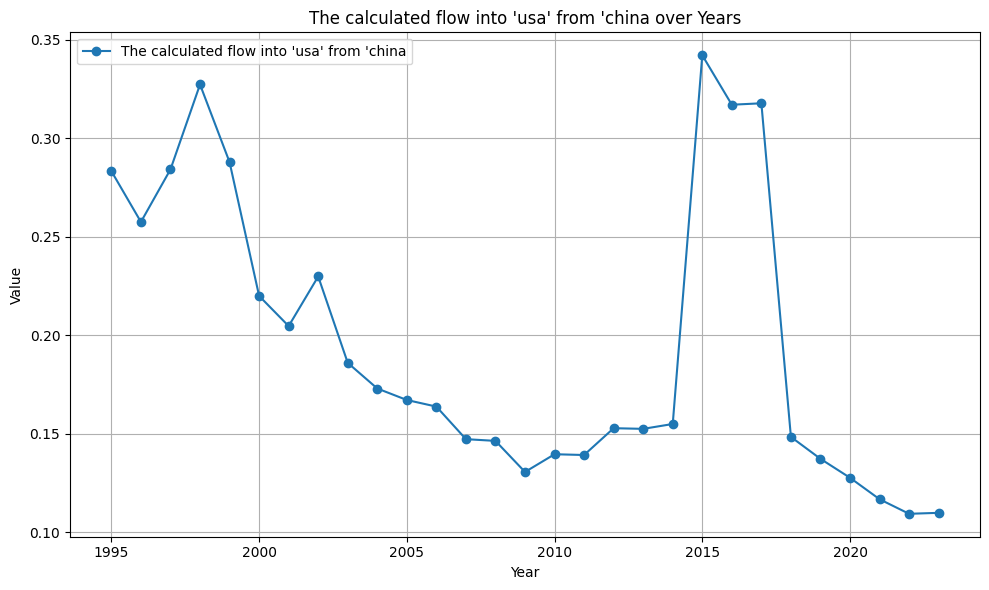

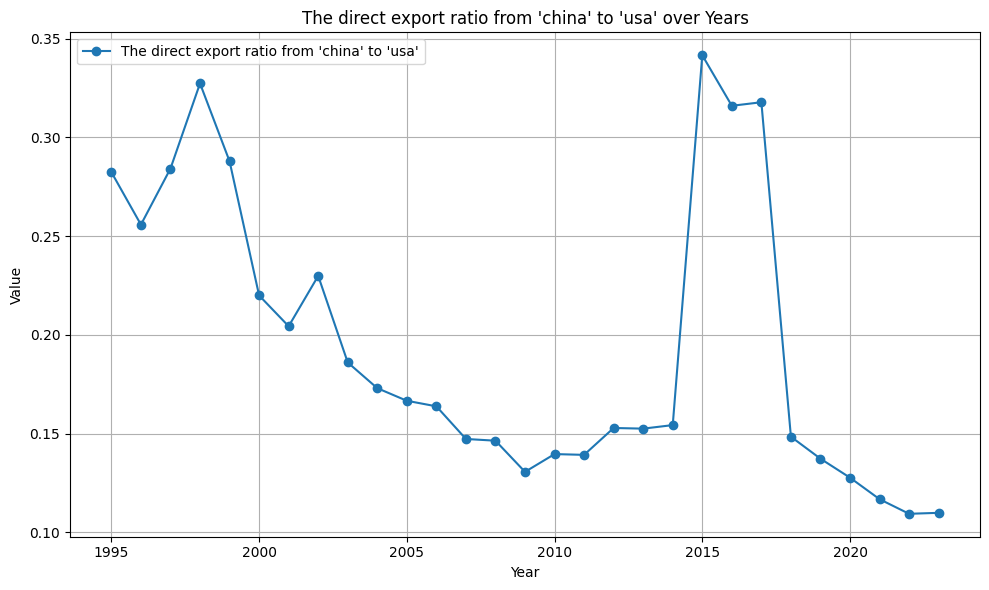

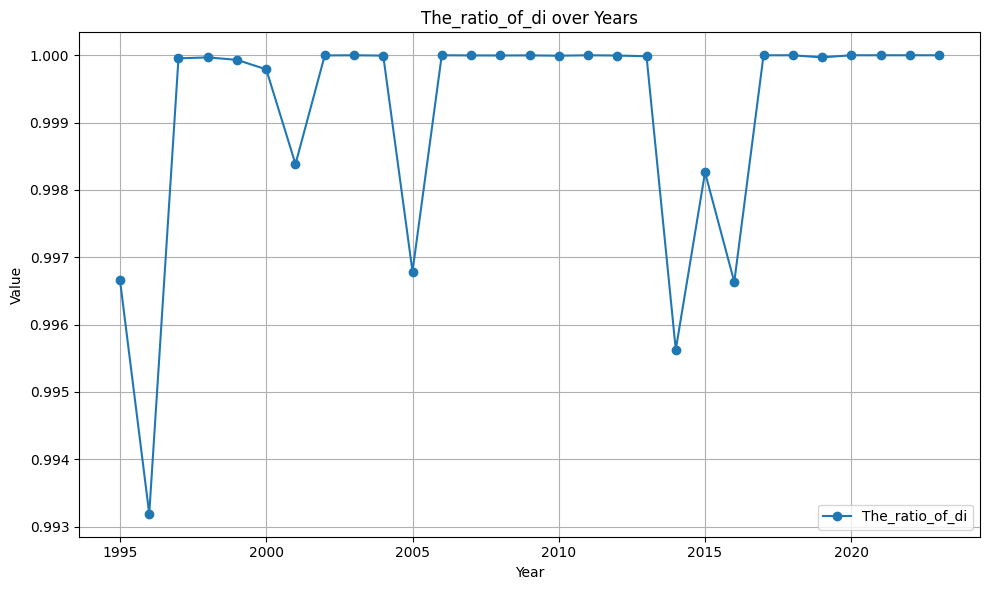

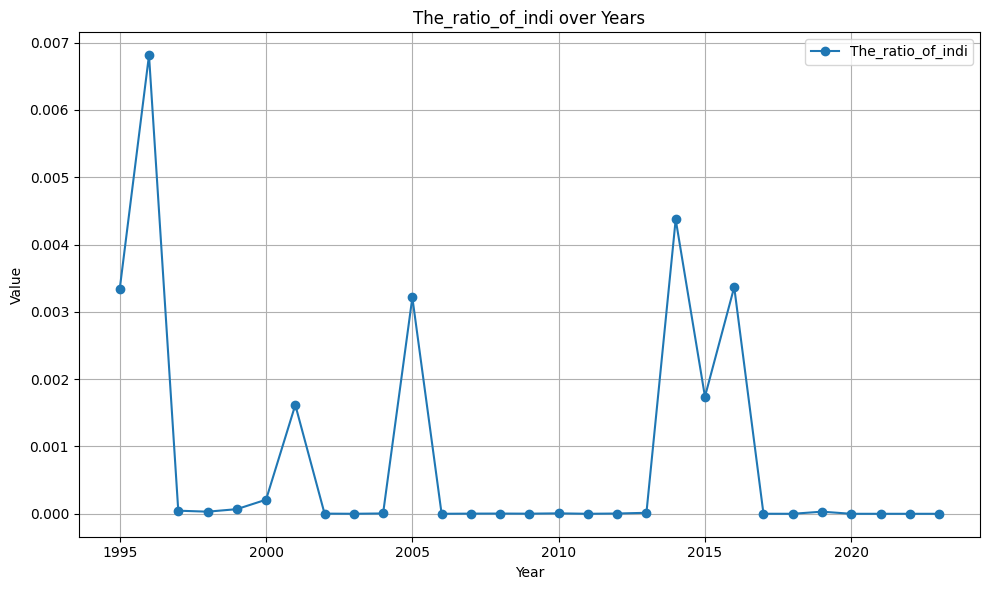

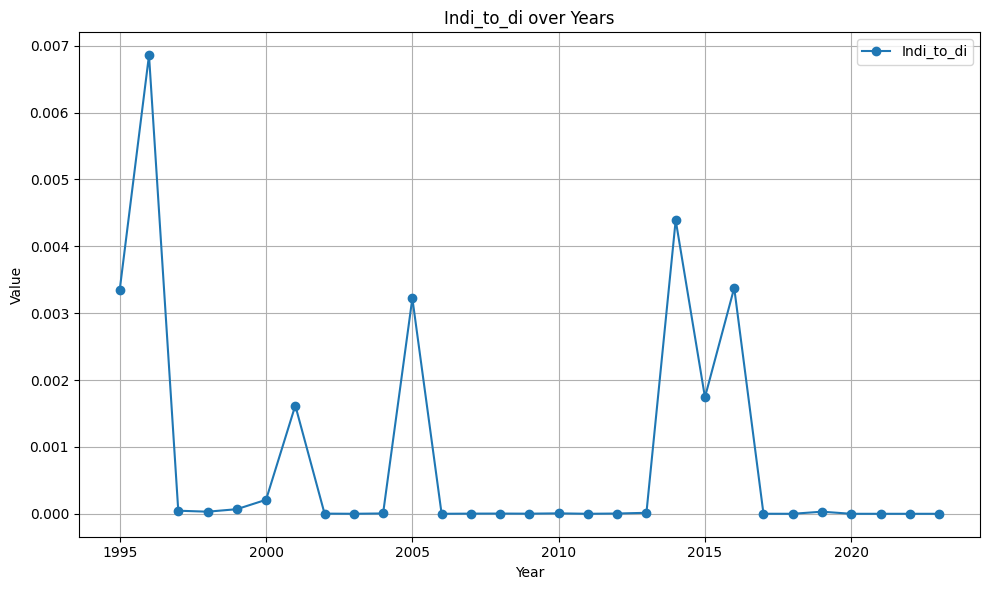

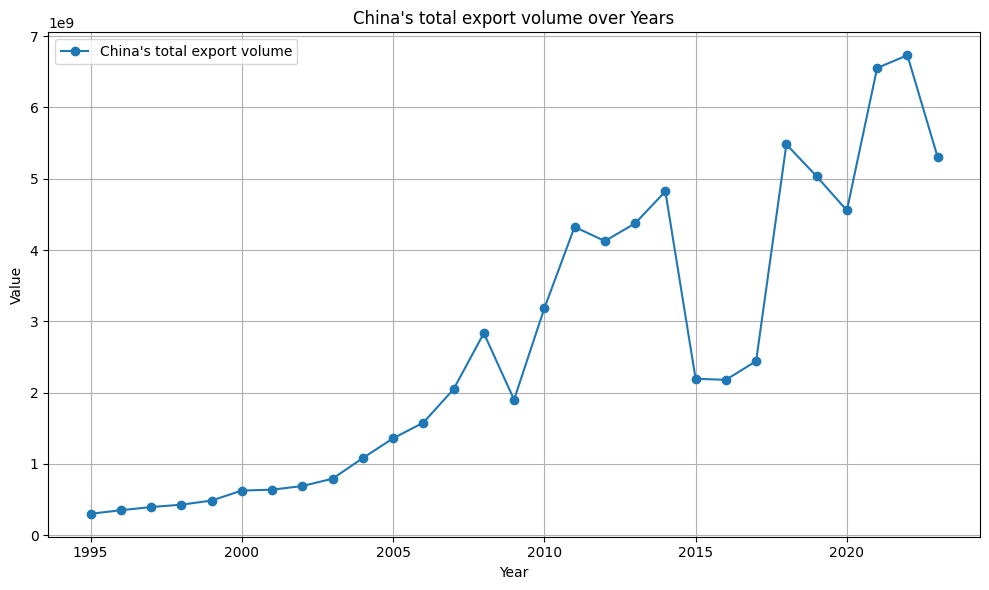

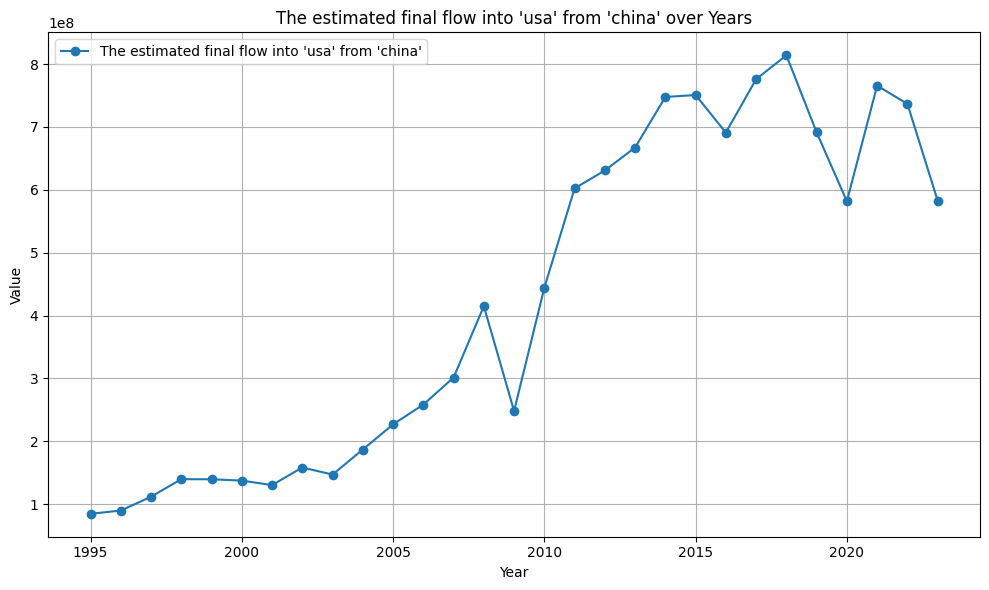

In [4]:
# 必要なデータを抽出
years = result['year']  # 'year'列を横軸として使用

# 'year' 以外のすべての列で折れ線グラフを作成
for column in result.columns:
    if column != 'year':  # 'year' 列はスキップ
        flow_values = result[column].astype(float)  # 対応する列を縦軸として使用

        # 折れ線グラフを作成
        plt.figure(figsize=(10, 6))
        plt.plot(years, flow_values, marker='o', linestyle='-', label=column)
        plt.xlabel('Year')
        plt.ylabel('Value')
        plt.title(f"{column} over Years")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()



＜中国の総輸出量＞
*   中国の総輸出量：2000年以降に徐々に増加し、2008年は一時減少する（おそらくリーマンショック）が、2年かけて回復。その後2014年まで横這いだが、2015年に急減し2017年まで低い水準を横這い。2018年に4倍以上に急増して回復、2020年にCOVID19によって一時落ち込むが、翌年には回復し2022年にピークとなった。
*   特に背景が不明なのは2015年～2017年の減少期。

＜calculated flow（中国からの全輸出量を１としたときの米国への直接・間接両方合わせた流入量）＞
*   1995年～2014年まではほぼ横ばい。
*   2015年～2016年に直間合わせても米国への流入量がほぼ０になっている。
*   そこから突然、2017年に急増している。中国の総輸出量自体はほぼ増えていないのに、直接・間接ともに米国への流入量が増えている。
*   また、おそらく制裁があったのは2015年であり、その後の2016年まではほぼ完璧な流入シャットアウトが実現している。その後の展開は、直接流入量で見ると、2017年に急増した後、2018年以降は制裁前の2014年以前よりやや低い水準で安定しているが、間接流入も合わせた推定値で見ると、2017年にはほぼ流入量は制裁前と同様の水準まで回復し、それ以降も2020年のコロナ禍の落ち込みを除くと上下はあるものの、制裁前と同様の水準まで回復している。

少なくとも、2015年～16年、2017年にはなんらかの情勢変化があったとみるべきであろう。






＜Rare Earth＞
*   HTSコードは "HTS Code: 2805.30 - Rare-earth Metals, Scandium And Yttrium, Whether Or Not Intermixed Or Interalloyed"
*   HSコードは "HS Code 28053000 | Harmonized System Code Rare-Earth Metals, Scandium And Yttrium, Whether Or Not Intermixed Or Interalloyed."（第28類　無機化学品及び貴金属、希土類金属、放射性元素又は同位元素の無機又は有機の化合物）



＜次にやりたいこと＞


*   穀類は少なくとも、トランプ政権下の制裁対象には入っていない。2017年以降にも特に間接・直接ともに減少を見せていない。
*   2016年や2017年のレアアースの変化が、レアアースのみの減少なのか、制裁が原因なのかはHTSコード8000番台と比べてみた方が良い。また、やはり2016年以前に貿易制裁はあったのかを調べるべき。

